## P(X) integration test


In this notebook we will integrate the density probability function $P(\widetilde{X})$ using two approach: 

1. Integrate in a hypervolume of 6 variables 

2. Integrate the positions ($x$,$y$,$z$) in a sphere and the velocities ($v_x$,$v_y$,$v_z$) in a cube

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters, 
    trasformation_X_to_E, 
    compute_jacobian_XoE,
    trasformation_E_to_X, 
    P_E_CMND,
    Jacobian_qei_to_QEI,
    computeNumericalJacobian,
)
import numpy as np
import multimin as mm
from tqdm import tqdm
import matplotlib.pyplot as plt
import spiceypy as spy
import seaborn as sns
import plotly.graph_objects as go


In [3]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

### Veryfing CMND fit 

C:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\jacobian_calculations\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


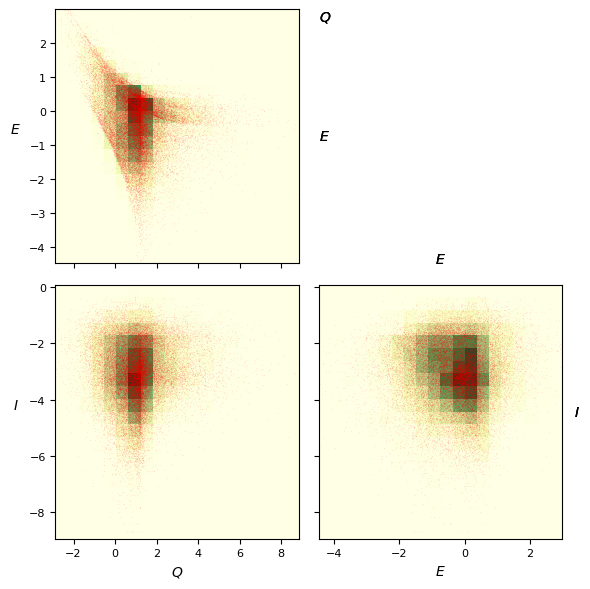

In [4]:
F = mm.FitCMND(f"../../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [5]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    #neas_number = 0
    #not_neas_number = 0

    for idx in range(x_flat.size):
        q, e, i, Omega, w, M, a = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        if q > 1.35 or e >= 1: 
            #v = (vx_flat[idx]**2 + vy_flat[idx]**2 + vz_flat[idx]**2)**0.5
            #print('evaluating: ', x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
            #print('not valid orbital elements: ', q, e, i, Omega, w, M, a, v)
            #if v > 8:
                #print('velocity is too high: ', v)
            P.flat[idx] = 0
            #neas_number += 1
        else: 
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
                if det == 0 or not np.isfinite(det):
                    #print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)
                    #not_neas_number += 1

                    #if np.isnan(P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)):
                    #    print('Nan value encounter: ', P_E_CMND(a, e, i, F), abs(inv_det), abs(det_QEI))
                    #    print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    
    return P.reshape(shape)

In [6]:
N = int(1e7)
fit_sample = F.cmnd.rvs(Nsam=N)

In [7]:
scales=[1.35,1.00,np.pi]
converted_sample = np.zeros_like(fit_sample)
for i, element in enumerate(fit_sample):
    converted_sample[i] = mm.Util.tIF(element, scales, mm.Util.u2f)

converted_sample

array([[0.81948674, 0.64814611, 0.20846318],
       [0.66208874, 0.41918453, 0.16953632],
       [0.8569636 , 0.09282893, 0.94664172],
       ...,
       [0.45196068, 0.78742994, 0.07137185],
       [0.63677394, 0.7605916 , 0.0248476 ],
       [0.74363835, 0.60437586, 0.05492924]])

In [8]:
q_CMND = converted_sample[:,0]
e_CMND = converted_sample[:,1]
i_CMND = converted_sample[:,2]

Omega_uniform = np.random.uniform(0, 2*np.pi, N)
w_uniform = np.random.uniform(0, 2*np.pi, N)
M_uniform = np.random.uniform(0, 2*np.pi, N)

elements = np.column_stack((q_CMND, e_CMND, i_CMND, Omega_uniform, w_uniform, M_uniform))

state_vectors = np.zeros((N, 6))
for el in tqdm(range(N)):
    q = q_CMND[el]
    e = e_CMND[el]
    i = i_CMND[el]
    Omega = Omega_uniform[el]
    w = w_uniform[el]
    M = M_uniform[el]

    x, y, z, vx, vy, vz = trasformation_E_to_X(q, e, i, Omega, w, M, mu)
    state_vectors[el] = np.array([x, y, z, vx, vy, vz])

100%|██████████| 10000000/10000000 [01:37<00:00, 102876.78it/s]


### Integration in hypercube 

In [9]:
def hypercube_surface_integral_P_X_CMND(center, widths, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        max_elemetns: tuple/list/array of (a_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    # Evaluate P at all points
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #return integral, y_points
    return integral

In [10]:
#max elements
max_elements = (1.35, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = hypercube_surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=8, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Theoretical (integral) number of objects in volume: 1698.0192692873645
Numerical (count) number of objects inside volume: 1814
Ratio 0.9360635442598482


### Locally Validation Monte Carlo Counts and P(X) 

#### Near Mercury orbit x = 0.4

In [ ]:
#max elements
max_elements = (1.35, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 0.4
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/0.4)**0.5
v_z = 0

dxyz = 0.1
dvxyz = 1000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = hypercube_surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=6, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Theoretical (integral) number of objects in volume: 0.00017984117232622125
Numerical (count) number of objects inside volume: 0
Ratio inf


C:\Users\aguju\AppData\Local\Temp\ipykernel_28264\2640128699.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  print('Ratio', (N_theoretical * N)/N_numeric)


#### Near Earth orbit x = 1.0

In [12]:
#max elements
max_elements = (1.35, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 1.0
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1.0)**0.5
v_z = 0

dxyz = 0.1
dvxyz = 1000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = hypercube_surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=6, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Theoretical (integral) number of objects in volume: 7.210733842336116
Numerical (count) number of objects inside volume: 7
Ratio 1.030104834619445


#### Near Mars orbit x = 1.52

In [71]:
#max elements
max_elements = (1.35, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 1.52
c_y = 0
c_z = 0

#a = np.sqrt((c_x**2 + c_y**2)) 
v_x = 0
v_y = (mu/1.52)**0.5
v_z = 0

dxyz = 0.1
dvxyz = 1000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = hypercube_surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=6, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dvxyz/2) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dvxyz/2) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dvxyz/2) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (N_theoretical * N)/N_numeric)

Theoretical (integral) number of objects in volume: 0.0007947838277872553
Numerical (count) number of objects inside volume: 0
Ratio inf


C:\Users\aguju\AppData\Local\Temp\ipykernel_28264\3625972317.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  print('Ratio', (N_theoretical * N)/N_numeric)


### Integral in a cube ($x$,$y$,$z$) and a in a sphere in ($v_x$,$v_y$,$v_z$)

In [13]:
def sphere_surface_integral_P_X_CMND(
    r: np.array,
    dr: np.array,
    c_v: np.array,
    r_v: float,
    deg: int,
    q_max: int, 
    e_max: int, 
    i_max: int,
    mu=1, 
    F=mm.FitCMND
) -> float:
    """
    Calculates the 6D integral of P_X_CMND using Gauss-Legendre Quadrature.
    Robust to P_X_CMND returning extra diagnostic values.
    """
    from numpy.polynomial.legendre import leggauss
    # 1. Get Gauss-Legendre nodes and weights
    nodes, weights = leggauss(deg)

    # 2. Velocity Mesh (Cartesian Box)
    x_vals = r[0] + dr[0] * nodes
    y_vals = r[1] + dr[1] * nodes
    z_vals = r[2] + dr[2] * nodes
    
    # 3. Position Mesh (Spherical Coordinates)
    # rho: [0, r], theta: [0, pi], phi: [0, 2pi]
    rho_vals = (r_v / 2.0) * (nodes + 1)
    theta_vals = (np.pi / 2.0) * (nodes + 1)
    phi_vals = np.pi * (nodes + 1)

    # 4. Construct the 6D Meshgrid
    # Order: rho, theta, phi, vx, vy, vz
    Rho, Theta, Phi, X, Y, Z = np.meshgrid(
        rho_vals, theta_vals, phi_vals, x_vals, y_vals, z_vals, indexing='ij'
    )
    
    # Mesh the weights
    W_rho, W_theta, W_phi, W_x, W_y, W_z = np.meshgrid(
        weights, weights, weights, weights, weights, weights, indexing='ij'
    )

    # 5. Coordinate Transformations
    sin_theta = np.sin(Theta)
    cos_theta = np.cos(Theta)
    sin_phi = np.sin(Phi)
    cos_phi = np.cos(Phi)
    
    VX = c_v[0] + Rho * sin_theta * cos_phi
    VY = c_v[1] + Rho * sin_theta * sin_phi
    VZ = c_v[2] + Rho * cos_theta

    # 6. Calculate Integration Weights (Jacobians)
    scale_factors = (r_v / 2.0) * (np.pi / 2.0) * np.pi * (dr[0] * dr[1] * dr[2])
    spherical_jacobian = (Rho**2) * sin_theta
    
    total_weights = (
        W_rho * W_theta * W_phi * W_x * W_y * W_z 
        * spherical_jacobian 
        * scale_factors
    )

    # 7. Evaluate Function
    P_output = P_X_CMND(X, Y, Z, VX, VY, VZ, q_max, e_max, i_max, mu, F=F)
        
    P_grid = P_output.reshape(total_weights.shape)
    
    weighted_values = P_grid * total_weights
    
    integral_result = np.sum(weighted_values)
    
    return integral_result

In [14]:
c_x, c_y, c_z = 1.0, 0.0, 0.0
center_pos = np.array([c_x, c_y, c_z])
dr = np.array([0.1, 0.1, 0.1])   

a = (c_x**2 + c_y**2)**0.5
vc = (mu/a)**0.5
v_x, v_y, v_z = 0.0, vc, 0.0
center_vel = np.array([v_x, v_y, v_z])

r_v = (2*mu/a)**0.5

degree = 6 
max_elements = (1.35, 1.0, np.pi) 

result = sphere_surface_integral_P_X_CMND(
    center_pos, dr, 
    center_vel, r_v, 
    degree, 
    q_max=max_elements[0], e_max=max_elements[1], i_max=max_elements[2], mu=mu, F=F
)

dvx = state_vectors[:, 3] - v_x
dvy = state_vectors[:, 4] - v_y
dvz = state_vectors[:, 5] - v_z
dist_sq = dvx**2 + dvy**2 + dvz**2

objs_vel_sphere = (dist_sq <= r_v)

objs_vx = (np.abs(state_vectors[:, 0] - c_x) <= dr[0])
objs_vy = (np.abs(state_vectors[:, 1] - c_y) <= dr[1])
objs_vz = (np.abs(state_vectors[:, 2] - c_z) <= dr[2])
objs_vel_box = objs_vx & objs_vy & objs_vz

objects_in_volume = objs_vel_sphere & objs_vel_box
N_numeric = objects_in_volume.sum()

In [15]:
print(f"Theoretical (integral) number of objects in volume: {result * N}")
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
print('Ratio', (result * N)/N_numeric)

Theoretical (integral) number of objects in volume: 13562.518837688025
Numerical (count) number of objects inside volume: 16078
Ratio 0.8435451447747248


### FIXED VELOCITY ($v_x = cte$, $v_y = cte$, $v_z = cte$)

In [12]:
def box_surface_integral_P_X_CMND(center, widths, velocities, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the integral of P_X_CMND over a position box (x, y, z) with fixed velocities.
    Integrates only over positions in a box centered at (cx, cy, cz) with widths (dx, dy, dz),
    while keeping velocities constant (vx = cte, vy = cte, vz = cte).

    Parameters:
        center: tuple/list/array of (cx, cy, cz) position center
        widths: tuple/list/array of (dx, dy, dz) position side lengths
        velocities: tuple/list/array of (vx, vy, vz) constant velocities
        max_elements: tuple/list/array of (q_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension
        mu: gravitational parameter
        F: FitCMND object

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    cx, cy, cz = center
    dx, dy, dz = widths
    vx, vy, vz = velocities
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for position dimensions only
    x_pts = cx + 0.5*dx*pts
    y_pts = cy + 0.5*dy*pts
    z_pts = cz + 0.5*dz*pts

    # Create meshgrid only for position quadrature points
    X, Y, Z = np.meshgrid(x_pts, y_pts, z_pts, indexing='ij')
    WX, WY, WZ = np.meshgrid(wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    WF = (WX * WY * WZ).ravel()
    
    # Create constant velocity arrays (same size as position arrays)
    VXf = np.full_like(Xf, vx)
    VYf = np.full_like(Yf, vy)
    VZf = np.full_like(Zf, vz)
    
    # Evaluate P at all points with constant velocities
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor (only position dimensions)
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz)
    return integral

In [15]:
#max elements
max_elements = (1.35, 1.0, np.pi)

# Define center and widths of the position box
c_x = 1
c_y = 0
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxyz = 0.2
# Small tolerance for velocity matching (in canonical units: AU/year)
# Using a very small tolerance since velocities are fixed constants
dv_tolerance = 1e-6

center = (c_x, c_y, c_z)
velocities = (v_x, v_y, v_z)
widths = (dxyz, dxyz, dxyz)

# Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = box_surface_integral_P_X_CMND(center, widths, velocities, max_elements=max_elements, n_points=8, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical * N}")

# Filter objects: positions within box AND velocities matching fixed values (within tolerance)
objsx = (abs(state_vectors[:,0] - c_x) <= dxyz/2) 
objsy = (abs(state_vectors[:,1] - c_y) <= dxyz/2) 
objsz = (abs(state_vectors[:,2] - c_z) <= dxyz/2) 
objsvx = (abs(state_vectors[:,3] - v_x) <= dv_tolerance) 
objsvy = (abs(state_vectors[:,4] - v_y) <= dv_tolerance) 
objsvz = (abs(state_vectors[:,5] - v_z) <= dv_tolerance) 

objects = objsx & objsy & objsz & objsvx & objsvy & objsvz
N_numeric = objects.sum()
print(f'Numerical (count) number of objects inside volume: {N_numeric}')
if N_numeric > 0:
    print('Ratio', (N_theoretical * N)/N_numeric)
else:
    print('Warning: No objects found with exact velocities. This is expected since velocities are fixed constants.')
    print(f'Objects in position box: {(objsx & objsy & objsz).sum()}')

Theoretical (integral) number of objects in volume: 3372.3202696758876
Numerical (count) number of objects inside volume: 0
Objects in position box: 18103


#### maping

In [42]:
def local_MC_vs_GL(
    c_x, c_y,
    state_vectors,
    N,
    mu, F,
    max_elements,
    dxyz, dvxyz,
    n_points=6,
):
    """
    Compare Monte Carlo counts vs Gauss–Legendre integral
    in a 6D hypercube centered at (c_x, c_y, 0, v_circ, 0).
    """

    # Fixed z-plane
    c_z = 0.0

    # Circular velocity at this radius
    r = np.sqrt(c_x**2 + c_y**2)
    v_circ = np.sqrt(mu / r)

    center = (c_x, c_y, c_z, 0.0, v_circ, 0.0)
    widths = (dxyz, dxyz, dxyz, dvxyz, dvxyz, dvxyz)

    # --- Theoretical count ---
    I_GL = hypercube_surface_integral_P_X_CMND(
        center,
        widths,
        max_elements=max_elements,
        n_points=n_points,
        mu=mu,
        F=F
    )

    N_theoretical = N * I_GL

    # --- Monte Carlo count ---
    mask = (
        (np.abs(state_vectors[:, 0] - c_x) <= dxyz / 2) &
        (np.abs(state_vectors[:, 1] - c_y) <= dxyz / 2) &
        (np.abs(state_vectors[:, 2] - c_z) <= dxyz / 2) &
        (np.abs(state_vectors[:, 3] - 0.0) <= dvxyz / 2) &
        (np.abs(state_vectors[:, 4] - v_circ) <= dvxyz / 2) &
        (np.abs(state_vectors[:, 5] - 0.0) <= dvxyz / 2)
    )

    N_numeric = mask.sum()

    return N_numeric, N_theoretical


In [74]:
# Grid definition (AU)
x_min, x_max = 0.4, 1.5
y_min, y_max = 0.4, 1.5
dx = 0.1

x_grid = np.arange(x_min, x_max + dx, dx)
y_grid = np.arange(y_min, y_max + dx, dx)

r_min, r_max = 0.4, 1.5

In [53]:
y_grid

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5])

In [76]:
results = []
dxyz = 0.1
dvxyz = 1000 * (1/AU_m) * year 
for x in x_grid:
    for y in y_grid:

        r = np.sqrt(x**2 + y**2)
        if (r < r_min) or (r > r_max):
            continue

        N_num, N_th = local_MC_vs_GL(
            c_x=x,
            c_y=y,
            state_vectors=state_vectors,
            N=N,
            mu=mu,
            F=F,
            max_elements=max_elements,
            dxyz=dxyz,
            dvxyz=dvxyz,
            n_points=6,
        )

        # --- Handle zero-count cases carefully ---
        if (N_num == 0) and (N_th == 0):
            ratio = 0         # undefined but harmless
            log_ratio = 0

        elif N_th == 0:
            ratio = np.nan            # integral predicts zero
            log_ratio = np.nan

        else:
            ratio = N_num / N_th
            #log_ratio = np.log10(ratio)

        results.append({
            "x": x,
            "y": y,
            "r": r,
            "N_numeric": N_num,
            "N_theoretical": N_th,
            "ratio": ratio
            #"log_ratio": log_ratio
        })


In [78]:
import pandas as pd

df = pd.DataFrame(results)

X = df["x"].values
Y = df["y"].values
R = df["ratio"].values
#LOGR = df["log_ratio"].values


In [73]:
df.to_csv('Ratio_1', index=False)

In [79]:
R

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       88.60897469,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.69174079,  0.        ,  0.        , 10.91166819,  0.        ,
        0.        ,  0.        ,  0.        ,  0.99300756,  0.  

In [47]:
R[100], R[103], R[56]

(1.1188166088198888, 2.3275291117659207, 4.145099850537636)

In [48]:
LOGR[100], LOGR[103], LOGR[56]

(0.048758904844009666, 0.3668951216620721, 0.6175349966511189)

In [80]:
def plot_planet_orbit(a, label, color, lw=1.5, ls="--"):
    theta = np.linspace(0, 2*np.pi, 500)
    x = a * np.cos(theta)
    y = a * np.sin(theta)
    plt.plot(x, y, ls=ls, lw=lw, color=color, label=label)

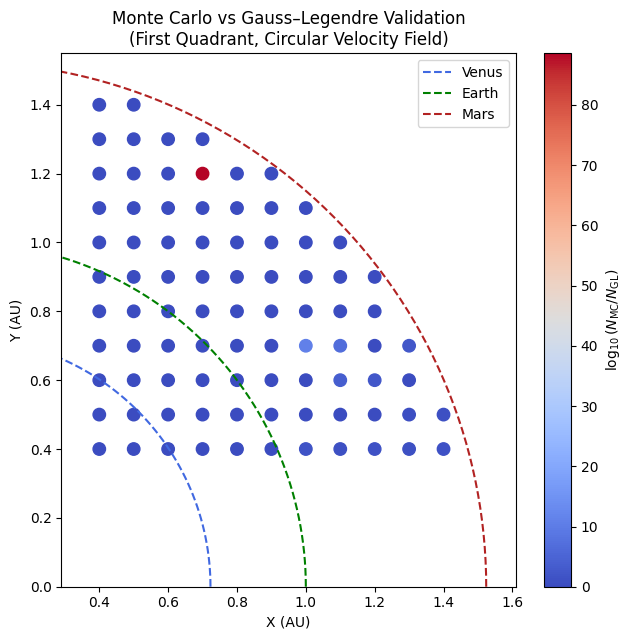

In [83]:
a_venus = 0.723
a_earth = 1.000
a_mars  = 1.524

plt.figure(figsize=(6.5, 6.5))

sc = plt.scatter(
    X, Y,
    c=R,
    cmap="coolwarm",
    s=80
    #vmin=-0.5,
    #vmax=0.5
)

# Planetary orbits
plot_planet_orbit(a_venus, "Venus", color="royalblue")
plot_planet_orbit(a_earth, "Earth", color="green")
plot_planet_orbit(a_mars,  "Mars",  color="firebrick")


# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label(r"$\log_{10}(N_\mathrm{MC} / N_\mathrm{GL})$")

# Labels and formatting
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.axis("equal")
plt.xlim(0.35, 1.55)
plt.ylim(0.00, 1.55)

plt.legend(loc="upper right", frameon=True)
plt.title("Monte Carlo vs Gauss–Legendre Validation\n(First Quadrant, Circular Velocity Field)")

plt.tight_layout()
plt.show()



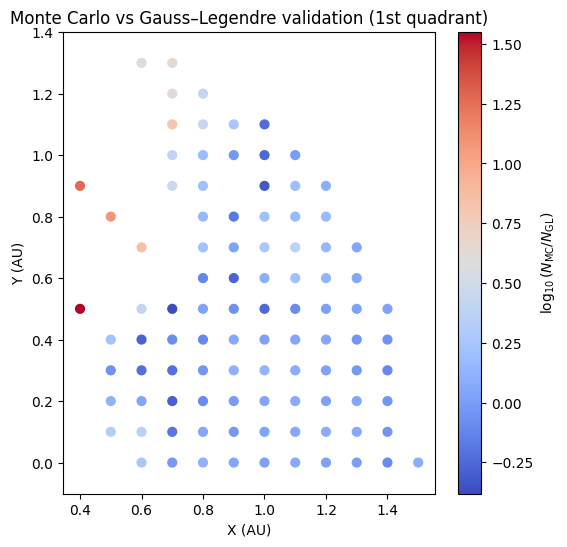

In [69]:
plt.figure(figsize=(6, 6))
sc = plt.scatter(X, Y, c=LOGR, cmap="coolwarm", s=40)
plt.colorbar(sc, label=r"$\log_{10}(N_\mathrm{MC} / N_\mathrm{GL})$")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.axis("equal")
plt.title("Monte Carlo vs Gauss–Legendre validation (1st quadrant)")
plt.show()


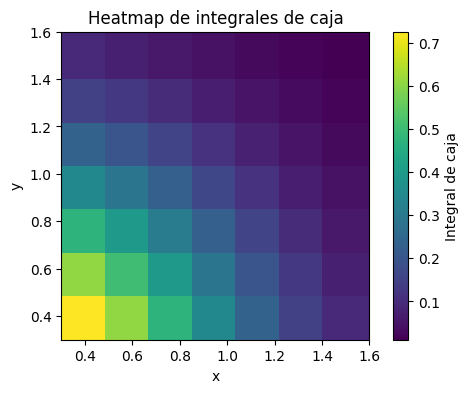

In [51]:
#dx = dy = 0.2

dtype = [
    ("x", float),
    ("y", float),
    ("value", float)
]

x_min, x_max = 0.4, 1.5
y_min, y_max = 0.4, 1.5

dx_cell, dy_cell = 0.2, 0.2

x_steps = int(round((x_max - x_min) / dx_cell)) + 1
y_steps = int(round((y_max - y_min) / dy_cell)) + 1

# Create arrays of the center points for each cell
xs = np.linspace(x_min, x_max, x_steps)
ys = np.linspace(y_min, y_max, y_steps)

# Grilla pequeña
#xs = np.array([0.4, 0.5, 0.6])
#ys = np.array([-0.1, 0.0, 0.1])

data = np.zeros((len(xs), len(ys)), dtype=dtype)

for i, x in enumerate(xs):
    for j, y in enumerate(ys):
        data[i, j]["x"] = x
        data[i, j]["y"] = y
        data[i, j]["value"] = np.exp(-(x**2 + y**2))  # valor de ejemplo

x_centers = data["x"][:, 0]
y_centers = data["y"][0, :]

x_edges = np.concatenate([
    x_centers - dx_cell/2,
    [x_centers[-1] + dx_cell/2]
])

y_edges = np.concatenate([
    y_centers - dy_cell/2,
    [y_centers[-1] + dy_cell/2]
])

Z = data["value"]

plt.figure(figsize=(6, 4))
pcm = plt.pcolormesh(
    x_edges,
    y_edges,
    Z.T,          # OJO con la transposición
    shading="flat",
)

plt.colorbar(pcm, label="Integral de caja")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Heatmap de integrales de caja")

plt.gca().set_aspect("equal")
plt.show()


In [52]:
y_centers

array([0.4       , 0.58333333, 0.76666667, 0.95      , 1.13333333,
       1.31666667, 1.5       ])